# 03 — Churn prediction models

**Goal:** rank customers by churn risk well enough to target retention spend — and report
performance honestly, given the 26.5% class imbalance (accuracy alone would mislead:
"nobody churns" scores 73%).

Two models on identical features (`src/modeling.py`):
- **Logistic regression** (L2, class-weighted) — the audit-friendly baseline
- **XGBoost** (300 trees, depth 3, `scale_pos_weight`) — the capacity upgrade

`TotalCharges` is excluded (≈ tenure × MonthlyCharges — collinear, no new information).

In [1]:
# Make the repo root importable when running from /notebooks
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

In [2]:
from src.data_prep import prepare
from src.modeling import run_modeling

df = prepare()
out = run_modeling(df)
m = out["metrics"]
pd.DataFrame({"Logistic regression": m["logistic"], "XGBoost": m["xgboost"]}).round(3)

C:\Users\shalo\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Logistic regression,XGBoost
roc_auc,0.838,0.844
pr_auc,0.627,0.662
precision_at_0.5,0.508,0.518
recall_at_0.5,0.778,0.789
f1_at_0.5,0.615,0.626
accuracy,0.741,0.749


XGBoost edges the baseline (ROC-AUC 0.844 vs 0.838, PR-AUC 0.662 vs 0.627) — a real
but modest gain. The logistic CV score (0.845 ± 0.012 across 5 folds) brackets the test
result, so the split isn't flattering us. Interestingly, a *bigger* XGBoost (500 trees,
depth 4) scored **worse** (0.833): with ~5,600 training rows, restraint beats capacity.

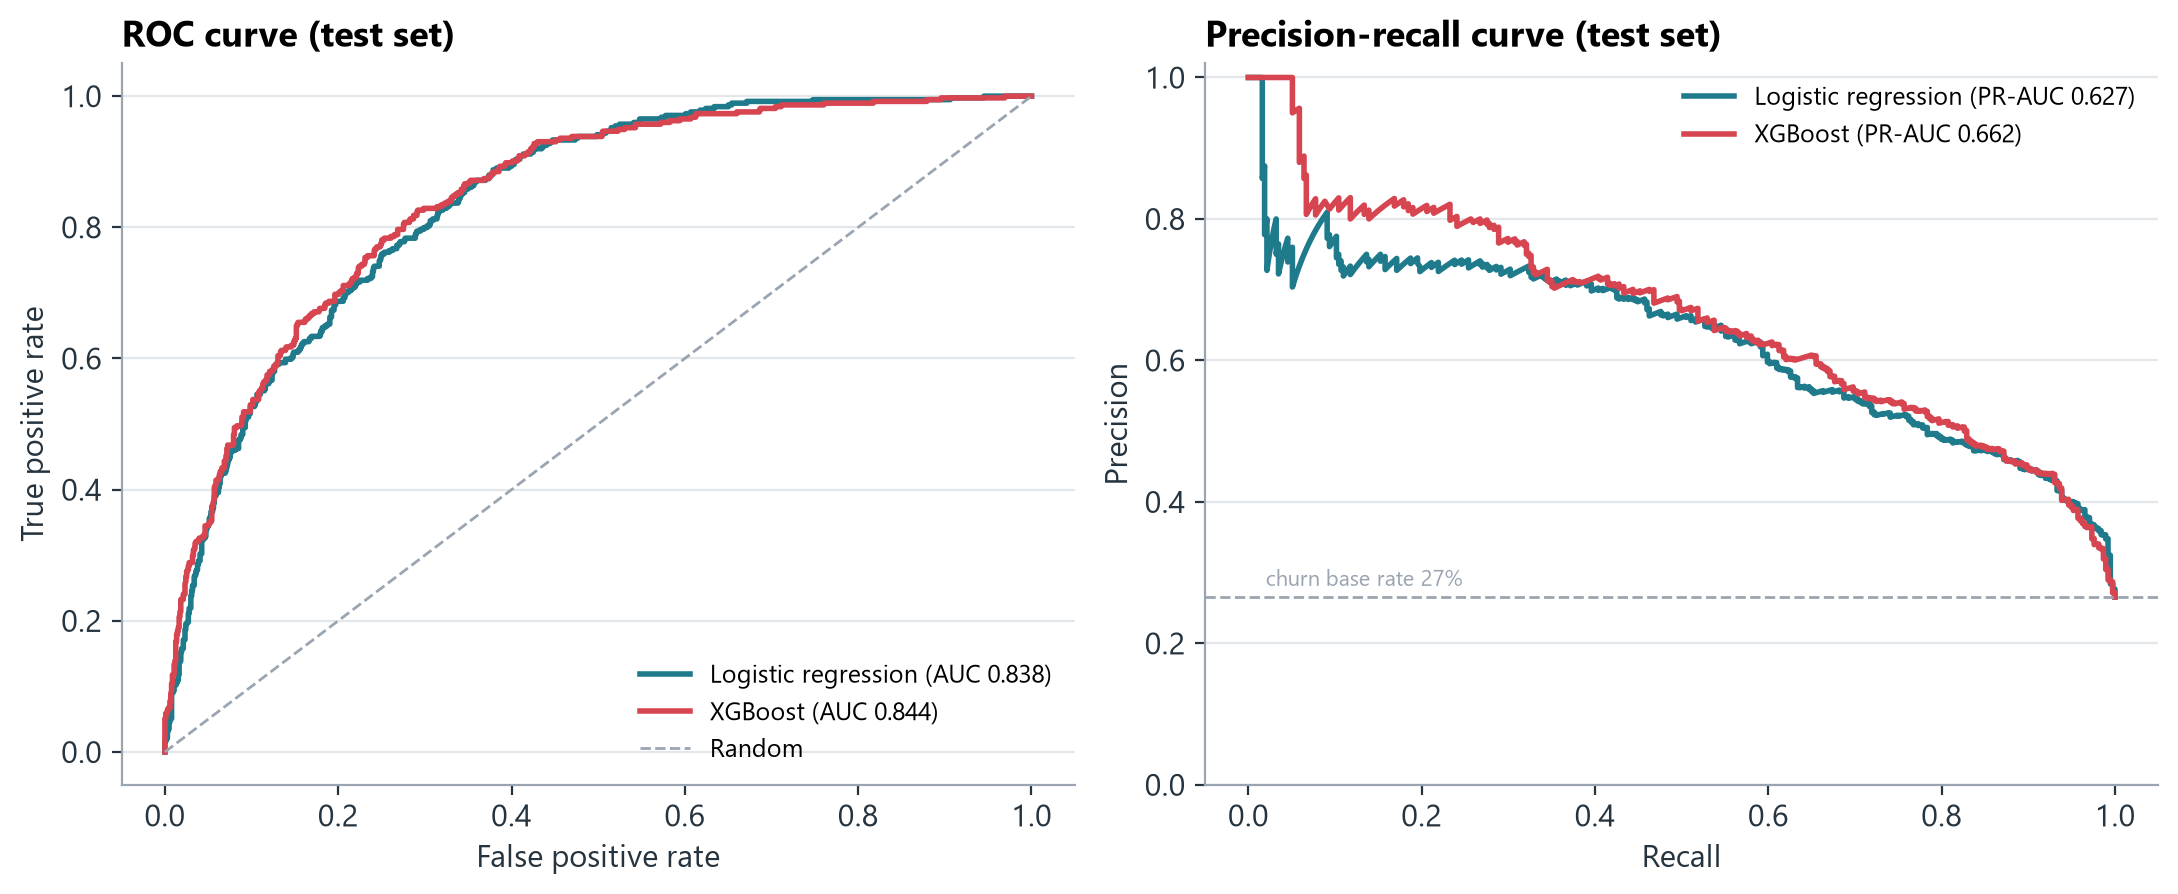

In [3]:
Image(out["figures"]["roc_pr"])

## The operating points that matter

A retention team contacts the riskiest N% it has budget for, so the useful question is
precision/recall *at campaign depth*, not at probability 0.5:

In [4]:
pd.DataFrame(m["xgboost_targeting"]).style.format(
    {"campaign_depth": "{:.0%}", "precision": "{:.1%}",
     "recall": "{:.1%}", "lift_vs_random": "{:.1f}x"})

,campaign_depth,customers_contacted,precision,recall,lift_vs_random
0,10%,141,76.6%,28.9%,2.9x
1,20%,282,67.4%,50.8%,2.5x
2,30%,423,58.9%,66.6%,2.2x


At 20% depth: two-thirds of contacted customers are genuine churn risks, and the
campaign reaches half of all churners — **2.5x better than untargeted outreach**. This is
the number the deck's ROI model uses.

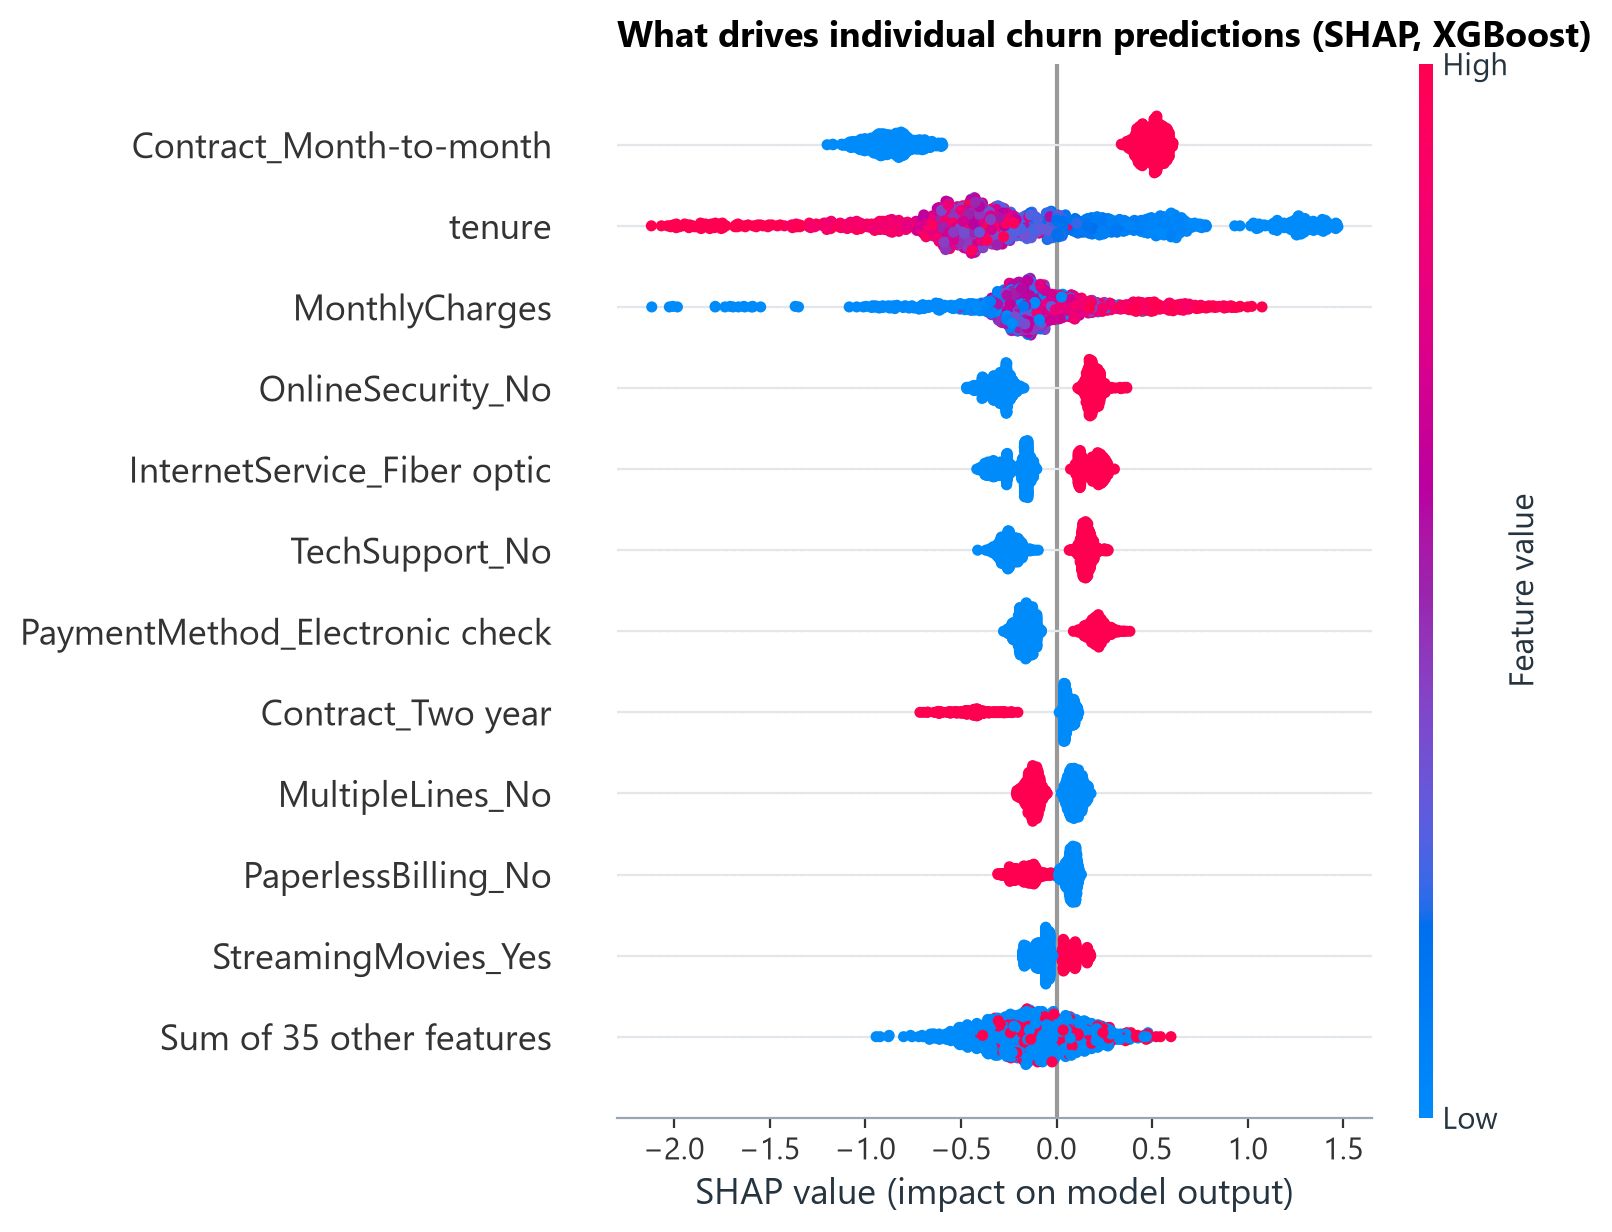

In [5]:
Image(out["figures"]["shap"])

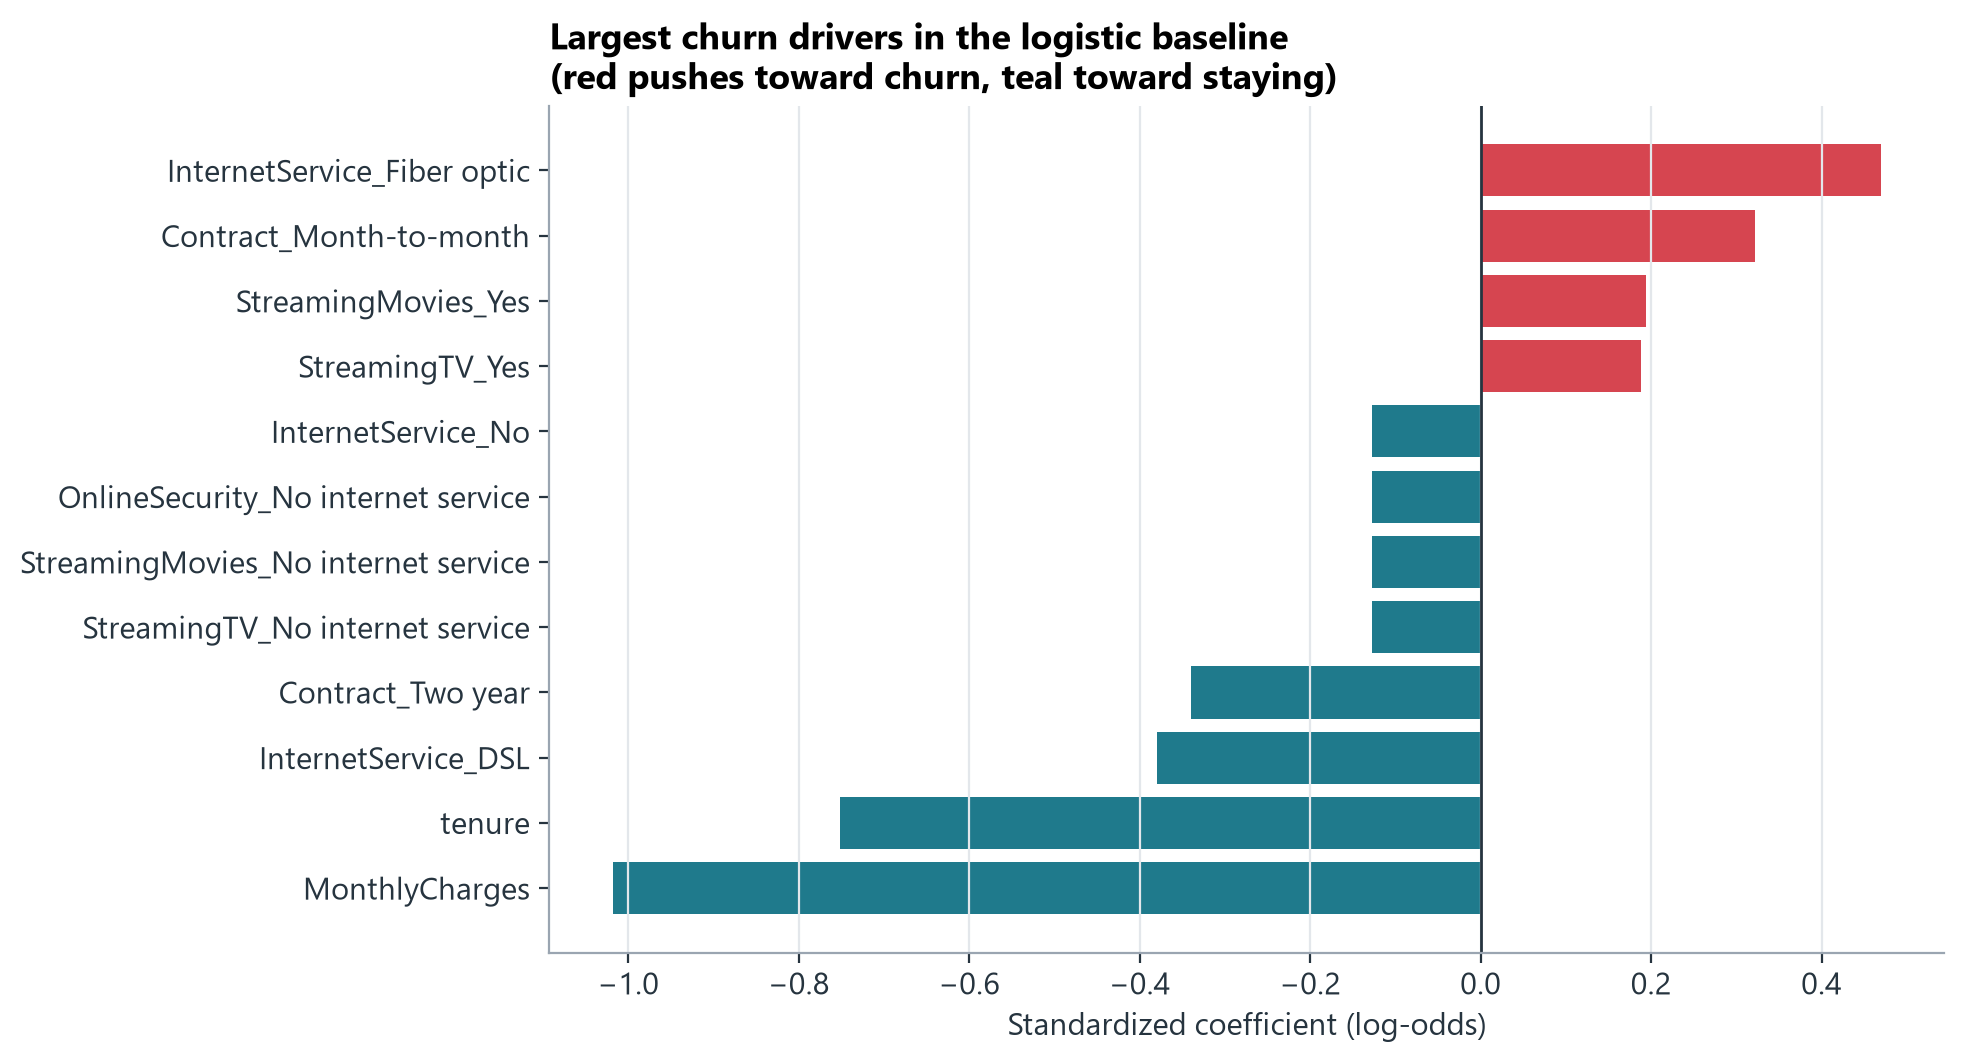

In [6]:
Image(out["figures"]["logit_coefs"])

## What drives predictions — and one trap

SHAP and the logistic coefficients agree with the EDA: month-to-month contracts, short
tenure, fiber-optic service, missing support add-ons, and electronic-check payment drive
risk. The model finds nothing the business can't act on — which is a feature, not a
disappointment.

**The trap:** `MonthlyCharges` gets a *negative* logistic coefficient while fiber-optic
gets a large positive one. They're highly correlated (fiber is expensive), so the linear
model splits one effect across two features. Read them jointly, or trust the SHAP view,
where high charges push toward churn overall.

Full limitations — snapshot data, unspecified label window, no behavioral features,
correlation ≠ causation — in [`reports/model-report.md`](../reports/model-report.md).